In [ ]:
!pip install kaggle

from google.colab import files
files.upload()

!kaggle datasets download -d polavr/twoclass-weather-classification

!unzip -q twoclass-weather-classification.zip -d weather_data

!ls weather_data

Saving archive.zip to archive.zip
Dataset URL: https://www.kaggle.com/datasets/polavr/twoclass-weather-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 107M/107M [00:05<00:00, 20.3MB/s]

test  train


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

train_dir = '/content/weather_data/train'
test_dir = '/content/weather_data/test'

batch_size = 20
image_size = (150, 150)

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training')

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation')

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=1,
    class_mode='binary',
    shuffle=False)

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size)

test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples)
print(f'Test accuracy: {test_acc:.3f}')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
!pip install kaggle -q

from google.colab import files
files.upload()

In [ ]:
!kaggle datasets download -d polavr/twoclass-weather-classification

!unzip -q twoclass-weather-classification.zip -d weather_data

!ls weather_data

Dataset URL: https://www.kaggle.com/datasets/polavr/twoclass-weather-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 107M/107M [00:01<00:00, 103MB/s] 

test  train


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

train_dir = '/content/weather_data/train'
test_dir = '/content/weather_data/test'

batch_size = 20
image_size = (150, 150)

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training')

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation')

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=1,
    class_mode='binary',
    shuffle=False)

print(f"\nعدد صور التدريب (Training samples): {train_generator.samples}")
print(f"عدد صور التحقق (Validation samples): {validation_generator.samples}")
print(f"عدد صور الاختبار (Test samples): {test_generator.samples}")

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
vgg_base.trainable = False

model_vgg = Sequential([
    vgg_base,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_vgg.summary()

print("\nبدء تدريب نموذج VGG16...")
history_vgg = model_vgg.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,  # تدريب لمدة 10 دورات
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

print("\nتقييم نموذج VGG16 على بيانات الاختبار...")
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_generator, steps=test_generator.samples)
print(f'\n========== النتيجة النهائية ==========')
print(f'دقة نموذج VGG16 على بيانات الاختبار: {test_acc_vgg:.3f} ({test_acc_vgg * 100:.2f}%)')

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 253 images belonging to 2 classes.

عدد صور التدريب (Training samples): 8000
عدد صور التحقق (Validation samples): 2000
عدد صور الاختبار (Test samples): 253


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,910,017 (72.14 MB)

 Trainable params: 4,195,329 (16.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


بدء تدريب نموذج VGG16...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3004s 8s/step - accuracy: 0.6876 - loss: 0.6174 - val_accuracy: 0.8000 - val_loss: 0.4589
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2997s 7s/step - accuracy: 0.7560 - loss: 0.4999 - val_accuracy: 0.8180 - val_loss: 0.4060
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2979s 7s/step - accuracy: 0.7616 - loss: 0.4789 - val_accuracy: 0.8225 - val_loss: 0.4232
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3018s 7s/step - accuracy: 0.7816 - loss: 0.4571 - val_accuracy: 0.8225 - val_loss: 0.3907
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3023s 7s/step - accuracy: 0.7860 - loss: 0.4441 - val_accuracy: 0.8450 - val_loss: 0.3536
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3019s 7s/step - accuracy: 0.7971 - loss: 0.4351 - val_accuracy: 0.8265 - val_loss: 0.3871
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2967s 7s/step - accuracy: 0.7975 - loss: 0.4261 - val_accuracy: 0.8380 - val_loss: 0.3488
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3059s 8s/step - accuracy

Found 253 images belonging to 2 classes.
253/253 ━━━━━━━━━━━━━━━━━━━━ 75s 289ms/step


<Figure size 600x600 with 0 Axes>

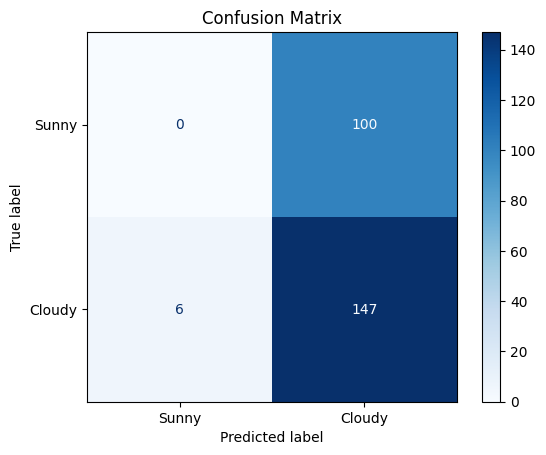

[[  0 100]
 [  6 147]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

test_dir = '/content/weather_data/test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sunny', 'Cloudy'])

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

print(cm)